<a href="https://colab.research.google.com/github/Devikrishna545/LLM-Scratch/blob/main/Simplified_attention_mechanism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#This is the sample code to demonstrate simplified attention mechanism without trainable weights.

#Self Attention without trainable weights

First we can see the steps to do simplified attention mechanism

1.word tokenization amd make the input embeddings

2.These input embeddings we select a query to know the attention with all other words , similarly create attention score matrix.

3.From these attention score create attention weight to make the interpretation easy.

4.Attention weights are multiplied  by the input embeddings to get the context vector matrix.

In [1]:
#for illustration choosing a random sentense and taking as tensors
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

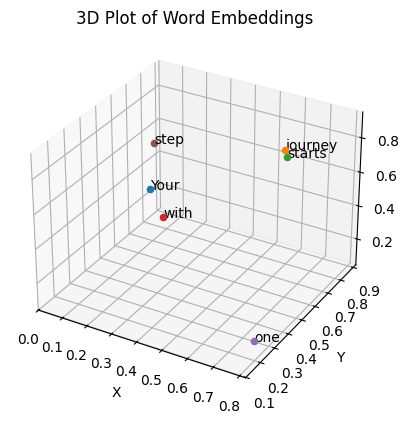

In [2]:
#to draw word plot embedding in 3d
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

words = ["Your","journey","starts","with","one","step"]
#extract x,y,z coordinates
xs = inputs[:, 0].numpy()
ys = inputs[:, 1].numpy()
zs = inputs[:, 2].numpy()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
#Plot each point and annotate with corresponding word

for x, y, z, word in zip(xs, ys, zs, words):
    ax.scatter(x, y, z)
    ax.text(x, y, z, word, fontsize=10)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title('3D Plot of Word Embeddings')
plt.show()

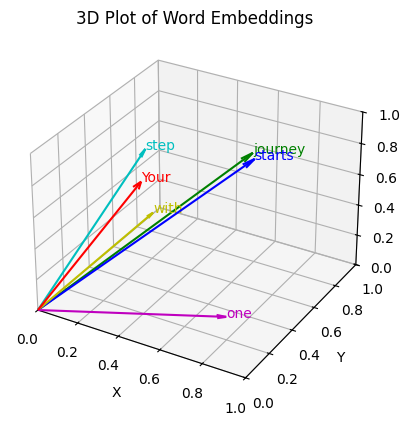

In [3]:
# Create 3D plot with vectors from origin to each point, using different colors
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

#colors for each vector arrows
colors = ['r', 'g', 'b', 'y', 'm', 'c']

#Plot each point and annotate with corresponding word

for x, y, z, word,color in zip(xs, ys, zs, words,colors):
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10,color=color)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Set plot limits to keep arrows within the plot boundaries
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

plt.title('3D Plot of Word Embeddings')
plt.show()

In [4]:
#step 2
#taking second input as query vector
query = inputs[1]

#to find the attention score we have to do the dot product of the query and other input vectors
#as its one dimention transpose not needed
attn_scores_2 = torch.empty(inputs.shape[0])

for i,x_i in enumerate (inputs):
  attn_scores_2[i]=torch.dot(query,x_i)

print(attn_scores_2)


tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In [5]:
#normalization of attention scores
#we normalize attention scores to make the values interpretable and
#the values sum all together makes one

attn_weights_2=attn_scores_2/attn_scores_2.sum()
print(attn_weights_2)

tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])


In [6]:
#but this computation is not proper when many long sequences comes up
#so for computational stability we use "softmax"
#exponential value softmax is used.
attn_weights_2=torch.softmax(attn_scores_2,dim=0)
print(attn_weights_2)
print("Sum:", attn_weights_2.sum())

tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


In [7]:
#to get the context vector of query 2
context_vector_2 =torch.zeros(query.shape)
for i,x_i in enumerate(inputs):
  context_vector_2 += x_i*attn_weights_2[i]
print(context_vector_2)



tensor([0.4419, 0.6515, 0.5683])


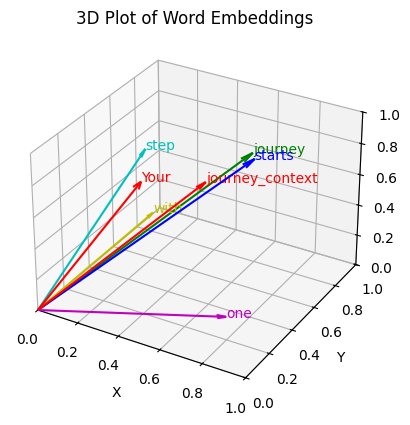

In [8]:
#plot context vector with other vector embeddings
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55],# step     (x^6)
   [0.4419, 0.6515, 0.5683]] #journey_context
)
words = ["Your","journey","starts","with","one","step","journey_context"]
#extract x,y,z coordinates
xs = inputs[:, 0].numpy()
ys = inputs[:, 1].numpy()
zs = inputs[:, 2].numpy()


# Create 3D plot with vectors from origin to each point, using different colors
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

#colors for each vector arrows
colors = ['r', 'g', 'b', 'y', 'm', 'c','r']

#Plot each point and annotate with corresponding word

for x, y, z, word,color in zip(xs, ys, zs, words,colors):
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10,color=color)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Set plot limits to keep arrows within the plot boundaries
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

plt.title('3D Plot of Word Embeddings')
plt.show()

In [9]:
#Now we can calculate all context vectors for the inputs
#there are 6 words in the input , so attention score matrix is 6x6 and input is 6x3
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]]
  )
attention_scores = torch.empty(6,6)
for i, x_i in enumerate(inputs):
  for j, x_j in enumerate(inputs):
    attention_scores[i,j]=torch.dot(x_i,x_j)
print(attention_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [10]:
attn_scores = inputs @ inputs.T
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [11]:
#calculate attention weights using softmax
attn_weights = torch.softmax(attn_scores,dim=1)
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [12]:
#to find context matrix
context_matrix = attn_weights @ inputs
print(context_matrix)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


#Self attention with trainable weights

Self attention with trainable weights can be done in steps

1.Input embeddings are multiplied with random weight matrices to get key, query, value matrices

2.Attention score is calculated by dot product query and key transpose.

3.Attention weight is calculted by normalizing attention score by softmax and square root of output_dimension.

4.Context vector is calculated by attention weight multiplied by values matrix

In [13]:
#for implementation, now we show the flow of working for the context vector of second word.
#input is taken as d_in=3 , d_out=2
x_2=inputs[1]
d_in=inputs.shape[1]
d_out = 2

In [14]:
#intializing random weights as Wk,Wq,Wv
torch.manual_seed(123)
W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

In [15]:
#multiplying input 2 with key , query, value
query_2 = x_2 @ W_query
key_2 = x_2 @ W_key
value_2 = x_2 @ W_value
print(query_2)
print(key_2)
print(value_2)

tensor([0.4306, 1.4551])
tensor([0.4433, 1.1419])
tensor([0.3951, 1.0037])


In [16]:
#calculate attention scores for query_2
#attn_scores_22 = query_2.dot(key_2)
#print(attn_scores_22) this dot product can be written as key transpose
keys = inputs @ W_key
querys = inputs@ W_query
attn_scores_2 = query_2 @ keys.T
print(attn_scores_2)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


In [17]:
#attention weight calculation with normalisation of score by softmax and square root of dimension of key shape

d_k = keys.shape[-1]
attn_weights_2 = torch.softmax(attn_scores_2/d_k**0.5,dim=0)
print(attn_weights_2)

tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])


We now compute the context vector as a weighted sum over the value
vectors.

In [18]:
#context vector
values = inputs @ W_value
context_2 = attn_weights_2@values
print(context_2)

tensor([0.3061, 0.8210])


In [19]:
#will find the context matrix
#create a class for selfattention with trainable weights and then find a context vector

import torch.nn as nn

class SelfAttention(nn.Module):
  def __init__(self,d_in,d_out):
    super().__init__()
    self.W_query = nn.Parameter(torch.rand(d_in, d_out), requires_grad=True)
    self.W_key = nn.Parameter(torch.rand(d_in, d_out),requires_grad=True)
    self.W_value = nn.Parameter(torch.rand(d_in, d_out),requires_grad=True)

  def forwardPass(self,x):
    keys = x @ self.W_key
    queries = x @ self.W_query
    values = x @ self.W_value
    attn_scores = queries @ keys.T
    d_k = keys.shape[-1]
    attn_weights = torch.softmax(attn_scores/d_k**0.5,dim=-1)
    context_matrix = attn_weights @ values
    return context_matrix



In [22]:
torch.manual_seed(123)
self_attnv1 = SelfAttention(d_in,d_out)
print(self_attnv1.forwardPass(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


computationally most efficient neural network is linear for self attention ,so we can change parametter to linear .Additionally, a significant advantage of using nn.Linear instead of manually
implementing nn.Parameter(torch.rand(...)) is that nn.Linear has an optimized weight
initialization scheme, contributing to more stable and effective model training.

In [23]:
class SelfAttentionV2(nn.Module):
  def __init__(self,d_in,d_out,qkv_bias = False):
    super().__init__()
    self.linear_k = nn.Linear(d_in,d_out,qkv_bias)
    self.linear_q = nn.Linear(d_in,d_out,qkv_bias)
    self.linear_v = nn.Linear(d_in,d_out,qkv_bias)
  def forwardPass(self,x):
    keys = self.linear_k(x)
    queries = self.linear_q(x)
    values = self.linear_v(x)
    attention_scores = queries @ keys.T
    d_k = keys.shape[-1]
    attn_weights = torch.softmax(attention_scores/d_k**0.5,dim=-1)
    context_matrix = attn_weights @ values
    return context_matrix

In [27]:
torch.manual_seed(789)
self_attnv2 = SelfAttentionV2(d_in,d_out)
print(self_attnv2.forwardPass(inputs))

tensor([[-0.0809,  0.0638],
        [-0.0784,  0.0657],
        [-0.0784,  0.0657],
        [-0.0772,  0.0666],
        [-0.0787,  0.0652],
        [-0.0769,  0.0669]], grad_fn=<MmBackward0>)
